In [40]:
import numpy as np
import pandas as pd
import seaborn as sns

In [7]:
from scipy.io import loadmat

data = loadmat('data/dfd-rutledge/Rutledge_risk_and_happiness_task_2023/Rutledge_GBE_risk_data_TOD.mat')
print(data.keys())  # Shows variable names in the .mat file
subj_data = data['subjData']

dict_keys(['__header__', '__version__', '__globals__', 'depData', 'subjData'])


In [17]:
def get_location(x):
    if  (x >=0) and (x <= 7):
        loc = 'United Kingdom'
    elif (x >=100) and (x <= 309):
        loc = 'Other Europe'
    elif x == 400:
        loc = 'USA'
    elif (x >=401) and (x <= 509):
        loc = 'Other North or South America'
    elif (x >=600) and (x <= 909):
        loc = 'Africa, Asia, Pacific'
    else:
        loc = 'Unknown'
    return loc

def get_life_satisfaction(x):
    return x

def get_education(x):
    if x == 0:
        edu = 'School (GCSE or similar)'
    elif x == 1:
        edu = 'School (A-levels, vocational, or similar)'
    elif x == 2:
        edu = 'University degree'
    elif x == 3:
        edu = 'Advanced degree (MA, PhD, etc)'
    return edu

def get_native_language(x):
    if x == 0:
        lang = 'Arabic'
    elif x == 1:
        lang = 'English'
    elif x == 2:
        lang = 'French'
    elif x == 3:
        lang = 'German'
    elif x == 4:
        lang = 'Hindi'
    elif x == 5:
        lang = 'Mandarin'
    elif x == 6:
        lang = 'Portuguese'
    elif x == 7:
        lang = 'Punjabi'
    elif x == 8:
        lang = 'Spanish'
    else:
        lang = 'Other'
    return lang

def get_age(x):
    if x == 1:
        age = '18-24'
    elif x == 2:
        age = '25-29'
    elif x == 3:
        age = '30-39'
    elif x == 4:
        age = '40-49'
    elif x == 5:
        age = '50-59'
    elif x == 6:
        age = '60-69'
    elif x == 7:
        age = '70+'
    else:
        age = 'unknown'
    return age

In [14]:
column_names = subj_data.dtype.names
num_participants = len(subj_data[0])
print(column_names)
print(num_participants)

('id', 'age', 'isFemale', 'location', 'lifeSatisfaction', 'education', 'nativeLanguage', 'deviceType', 'nPlays', 'timesPlayed', 'dayNumber', 'timeOfDay', 'designVersion', 'dataHdr', 'data')
47067


In [18]:
participant = 0


for participant in range(num_participants):
    participant_data = subj_data[0][participant]
    id = participant_data[0].item()
    age = get_age(participant_data[1].item())
    gender = 'female' if participant_data[2].item() else 'male'
    location = get_location(participant_data[3].item())
    life_satisfaction = get_life_satisfaction(participant_data[4].item())
    education = get_education(participant_data[5].item())
    native_language = get_native_language(participant_data[6].item())
    
    max_sessions = 0
    
    num_sessions = len(participant_data[14][0])
    num_sessions = min(num_sessions, 30)
    if num_sessions > max_sessions:
        max_sessions = num_sessions
    for session in range(num_sessions):
        session_data = participant_data[14][0][session]
        for trial in range(session_data.shape[0]):
            certain_value = session_data[trial, 2]
            win_value = session_data[trial, 3]
            lose_value = session_data[trial, 4]
            c = int(session_data[trial, 6])
            reward = session_data[trial, 7]
            rt_choice = session_data[trial, 8] * 1000

In [34]:
# Initialize list to collect all trial records
all_trials = []

for participant in range(num_participants):
    participant_data = subj_data[0][participant]
    
    # Extract participant-level metadata
    id = participant_data[0].item()
    age = get_age(participant_data[1].item())
    gender = 'female' if participant_data[2].item() else 'male'
    location = get_location(participant_data[3].item())
    life_satisfaction = get_life_satisfaction(participant_data[4].item())
    education = get_education(participant_data[5].item())
    native_language = get_native_language(participant_data[6].item())
    
    # Limit number of sessions
    num_sessions = len(participant_data[14][0])
    num_sessions = min(num_sessions, 30)
    
    for session in range(num_sessions):
        session_data = participant_data[14][0][session]
        
        for trial in range(session_data.shape[0]):
            trial_record = {
                'participant_id': id,
                'age': age,
                'gender': gender,
                'location': location,
                'life_satisfaction': life_satisfaction,
                'education': education,
                'native_language': native_language,
                'session': session + 1,
                'trial': trial + 1,
                'certain_value': session_data[trial, 2],
                'win_value': session_data[trial, 3],
                'lose_value': session_data[trial, 4],
                'chose_risky': int(session_data[trial, 6]),
                'reward': session_data[trial, 7],
                'rt_choice_ms': session_data[trial, 8] * 1000
            }
            all_trials.append(trial_record)

# Convert to DataFrame
df = pd.DataFrame(all_trials)


In [36]:
df.head()

,participant_id,age,gender,location,life_satisfaction,education,native_language,session,trial,certain_value,win_value,lose_value,chose_risky,reward,rt_choice_ms
0,1,30-39,male,United Kingdom,8,"Advanced degree (MA, PhD, etc)",Other,1,1,-55.0,0.0,-220.0,1,-220.0,18239.0
1,1,30-39,male,United Kingdom,8,"Advanced degree (MA, PhD, etc)",Other,1,2,45.0,122.0,0.0,0,45.0,5023.0
2,1,30-39,male,United Kingdom,8,"Advanced degree (MA, PhD, etc)",Other,1,3,55.0,132.0,0.0,1,132.0,4317.0
3,1,30-39,male,United Kingdom,8,"Advanced degree (MA, PhD, etc)",Other,1,4,-35.0,0.0,-70.0,0,-35.0,6357.0
4,1,30-39,male,United Kingdom,8,"Advanced degree (MA, PhD, etc)",Other,1,5,-55.0,0.0,-120.0,0,-55.0,9397.0


<Axes: xlabel='session', ylabel='Count'>

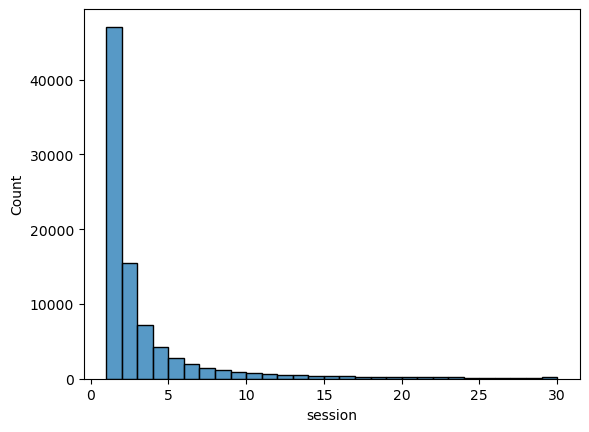

In [44]:
df["rwn"] = df.groupby(["participant_id", "session"]).cumcount() + 1
df_plt = df.query("rwn == 1")

sns.histplot(data=df_plt, x="session", binwidth=1)

<Axes: xlabel='session', ylabel='Count'>

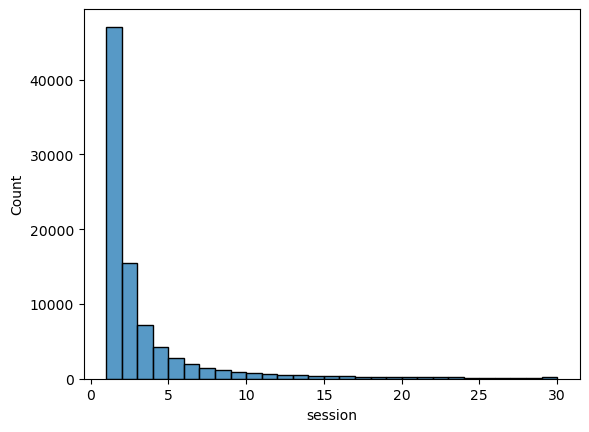

In [46]:
sns.histplot(data=df_plt, x="session", binwidth=1)